# ROMP Milestone 2 — progression verification

Onset is not just a DOY scalar per grid cell — it is an **advancing front**.
This notebook demonstrates the three Milestone-2 metrics that treat onset
as a moving contour:

1. **Integrated Onset Error (IOE)** — area of symmetric difference between
   forecast and observed "onset-by-d" masks, integrated over the season.
2. **Spatial Probability Score (SPS)** — the ensemble generalization; a
   per-cell Brier score of P(onset ≤ d) against the observed indicator.
3. **Isochrone overlays + Fréchet / Hausdorff distances** — the **§7
   Milestone-2 success-criterion artifact**: a hero figure showing how
   forecast and observed onset contours evolve through the season.

We use a reproducible synthetic advancing-front case; plugging in real
onset-DOY fields from the ROMP pipeline is a one-line change.


In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from momp.metrics.progression import integrated_onset_error, spatial_probability_score
from momp.graphics.isochrone import isochrone_distance_sweep, isochrone_overlay


## Synthetic advancing front

A northward-propagating monsoon front on an Indian-subcontinent-style
domain (8–35°N, 70–95°E). Onset advances about one degree of latitude per
2.5 days. The forecast is delayed ~8 days and drifts ~1.5° east with lead.


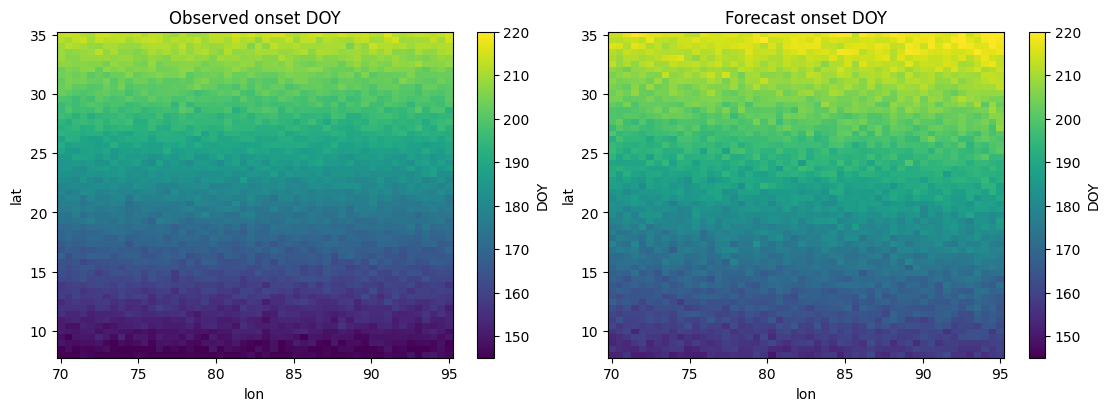

In [2]:
rng = np.random.default_rng(2026)
lats = np.linspace(8.0, 35.0, 56)
lons = np.linspace(70.0, 95.0, 52)
LAT, LON = np.meshgrid(lats, lons, indexing="ij")

def front(lat, lon, a0=145.0, b=2.5, drift_lon=0.0, noise=1.0, rng_=None):
    val = a0 + b * (lat - 8.0) + drift_lon * (lon - 70.0)
    if rng_ is not None:
        val = val + noise * rng_.standard_normal(lat.shape)
    return val

obs_doy = front(LAT, LON, a0=145.0, b=2.5, drift_lon=0.0, noise=1.5, rng_=rng)
fcst_doy = front(LAT, LON, a0=153.0, b=2.3, drift_lon=0.18, noise=2.0, rng_=rng)

obs = xr.DataArray(obs_doy, coords={"lat": lats, "lon": lons}, dims=("lat", "lon"))
fcst = xr.DataArray(fcst_doy, coords={"lat": lats, "lon": lons}, dims=("lat", "lon"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, da, title in zip(axes, [obs, fcst], ["Observed onset DOY", "Forecast onset DOY"]):
    im = ax.pcolormesh(lons, lats, da.values, cmap="viridis", vmin=145, vmax=220)
    ax.set_xlabel("lon"); ax.set_ylabel("lat"); ax.set_title(title)
    fig.colorbar(im, ax=ax, label="DOY")
plt.show()


## 1. Integrated Onset Error

Compute IOE at a 5-day cadence through the season and plot the three
series: total IOE, the extent (area-bias) component, and the misplacement
(geographic) component. Misplacement is the piece of the error that would
persist even if the forecast's total onset area were exactly right.


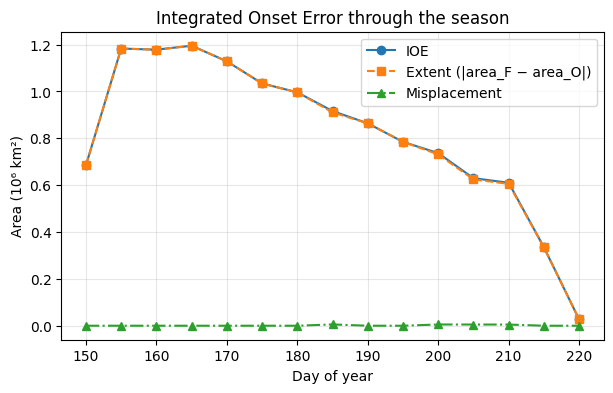

Season-integrated IOE         : 59.738 10⁶ km²·day
Season-integrated extent      : 59.635 10⁶ km²·day
Season-integrated misplacement: 0.104 10⁶ km²·day


In [3]:
days = list(range(150, 221, 5))
ds_ioe = integrated_onset_error(fcst, obs, days=days)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ds_ioe["day"], ds_ioe["ioe_km2"] / 1e6, "o-", label="IOE")
ax.plot(ds_ioe["day"], ds_ioe["extent_km2"] / 1e6, "s--", label="Extent (|area_F − area_O|)")
ax.plot(ds_ioe["day"], ds_ioe["misplacement_km2"] / 1e6, "^-.", label="Misplacement")
ax.set_xlabel("Day of year"); ax.set_ylabel("Area (10⁶ km²)")
ax.set_title("Integrated Onset Error through the season")
ax.grid(alpha=0.3); ax.legend()
plt.show()

print(f"Season-integrated IOE         : {float(ds_ioe['ioe_season_km2_day']) / 1e6:.3f} 10⁶ km²·day")
print(f"Season-integrated extent      : {float(ds_ioe['extent_season_km2_day']) / 1e6:.3f} 10⁶ km²·day")
print(f"Season-integrated misplacement: {float(ds_ioe['misplacement_season_km2_day']) / 1e6:.3f} 10⁶ km²·day")


## 2. Spatial Probability Score

A 15-member ensemble (members perturbed around the forecast mean). SPS
integrates per-cell Brier scores of P(onset ≤ d) against the observed
indicator. For a 1-member deterministic ensemble, SPS == IOE.


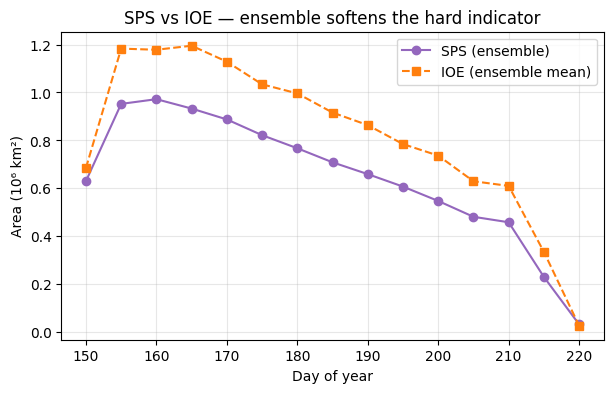

Season-integrated SPS: 46.796 10⁶ km²·day


In [4]:
n_members = 15
member_noise = 3.5 * rng.standard_normal((n_members,) + fcst_doy.shape)
ensemble = fcst_doy[None, ...] + member_noise
ens = xr.DataArray(
    ensemble,
    dims=("member", "lat", "lon"),
    coords={"member": np.arange(n_members), "lat": lats, "lon": lons},
)

ds_sps = spatial_probability_score(ens, obs, days=days)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ds_sps["day"], ds_sps["sps_km2"] / 1e6, "o-", color="tab:purple", label="SPS (ensemble)")
ax.plot(ds_ioe["day"], ds_ioe["ioe_km2"] / 1e6, "s--", color="tab:orange",
        label="IOE (ensemble mean)")
ax.set_xlabel("Day of year"); ax.set_ylabel("Area (10⁶ km²)")
ax.set_title("SPS vs IOE — ensemble softens the hard indicator")
ax.grid(alpha=0.3); ax.legend()
plt.show()

print(f"Season-integrated SPS: {float(ds_sps['sps_season_km2_day']) / 1e6:.3f} 10⁶ km²·day")


### Sanity check: deterministic ensemble reduces to IOE

In [5]:
ens_det = xr.DataArray(
    fcst_doy[None, ...],
    dims=("member", "lat", "lon"),
    coords={"member": [0], "lat": lats, "lon": lons},
)
ds_sps_det = spatial_probability_score(ens_det, obs, days=days)
diff = np.abs(ds_sps_det["sps_km2"].values - ds_ioe["ioe_km2"].values).max()
print(f"max |SPS_det − IOE| across days: {diff:.3e} km²  (should be ~0)")


max |SPS_det − IOE| across days: 0.000e+00 km²  (should be ~0)


## 3. Isochrone overlays — the §7 hero figure

Extract forecast and observed onset contours (isochrones) at several
calendar DOYs and overlay them on one map. The gap between matching
contours tells you how far off the forecast is in space at that date.


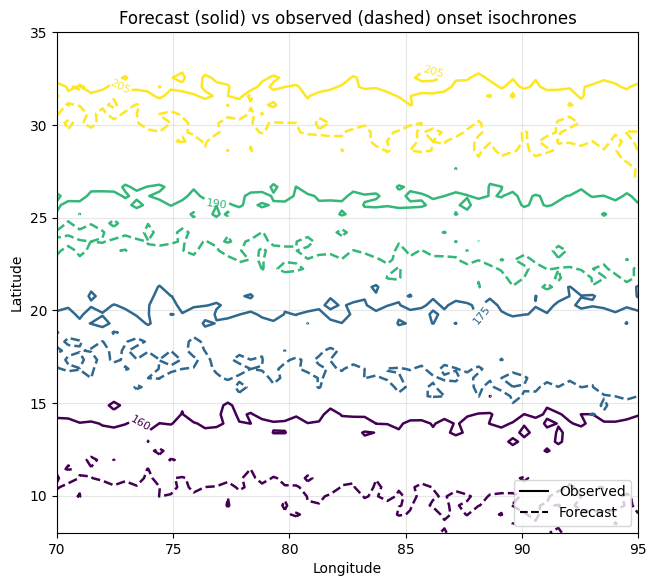

In [6]:
iso_days = [160, 175, 190, 205]

fig = isochrone_overlay(
    fcst, obs,
    days=iso_days,
    title="Forecast (solid) vs observed (dashed) onset isochrones",
    show=False,
)
fig.set_size_inches(7.5, 6.5)
plt.show()


### Fréchet / Hausdorff distance per isochrone

Summarise each forecast-vs-observed contour pair with two contour
distances. Hausdorff is the worst-case point-to-set distance; Fréchet
respects parameterisation order along the contour.


     hausdorff_km   frechet_km  n_segments_fcst  n_segments_obs
day                                                            
160    589.214945  1987.128745               20              11
175    636.219387  1505.681092               15              16
190    499.578663  1126.379515               23              12
205    554.672836  2809.640351               14              11


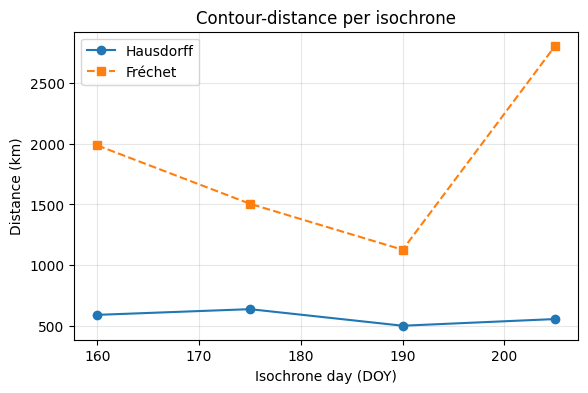

In [7]:
ds_iso = isochrone_distance_sweep(fcst, obs, days=iso_days)
print(ds_iso[["hausdorff_km", "frechet_km", "n_segments_fcst", "n_segments_obs"]].to_dataframe())

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(ds_iso["day"], ds_iso["hausdorff_km"], "o-", label="Hausdorff")
ax.plot(ds_iso["day"], ds_iso["frechet_km"], "s--", label="Fréchet")
ax.set_xlabel("Isochrone day (DOY)"); ax.set_ylabel("Distance (km)")
ax.set_title("Contour-distance per isochrone")
ax.grid(alpha=0.3); ax.legend()
plt.show()


## Pulling it together

Everything shown above is wired into the `momp-run-progression` CLI:

```
momp-run-progression \
    --forecast path/to/forecast_onset.nc \
    --observed path/to/observed_onset.nc \
    --season-end 220 \
    --days 150:220:5 \
    --output-dir results/
```

`progression_verification()` in `momp.app.progression_verification` is
the same orchestration you'd call directly from Python.
